In [2]:
import numpy as np 
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

from time import time as t

import sys
sys.path.append('..')

import PyESRSTM

In [3]:
eps = -5.2
U = 100
B1 = np.array([0.233128615332, 0, 0.0411068648582])
B2 = np.array([0.246201938253, 0, 0.0434120444167])

g1 = np.array([[1.82150243992, 0.128387131107, -0.0186440621011],  # Local gyromagnetic factors
            [0.128387131107, 1.75163172705, 0.00216036917748],
            [-0.0186440621011, 0.00216036917748, 1.98586583303]])
g2 = np.array([[2.0082426119, 0.681792621257, -1.28905279088],  # Local gyromagnetic factors
            [0.681792621257, 1.53118274595, -0.580677167073],
            [-1.28905279088, -0.580677167073, 9.29467464215]])

Jexch = np.array([[0.431405352319, 0.312911794264, -0.190209017664],  # Jx, Jy, Jz in GHz
                [0.312911794264, 0.248216060931, -0.0667695556565],
                [-0.190209017664, -0.0667695556565, 1.61221255695]])

gR =.005
gL =.001
Ecut = 200
gC = 0.001
Nint = 500000 

VR = 5.
VL = -5.
T = .7 
PL = 0.5

dot = PyESRSTM.QD(eps, U, np.array([0.5, 0.5]), np.array([B1, B2]), 
            np.array([g1, g2]),Jexch=[[Jexch,0,1],], gyro_to_J=False)

Right = PyESRSTM.Electrode(VR,   0, 0., gR, gC, T,  Nint=Nint, Cutoff=Ecut)
Left = PyESRSTM.Electrode(VL, 0, PL, gL, gC, T, Nint=Nint, Cutoff=Ecut, Adrive=0)

Hermiticity check passed!
Hermiticity check passed!


In [4]:
GRplus, GRminus = PyESRSTM.rates(dot, Right, 0,  0)
GLplus, GLminus = PyESRSTM.rates(dot, Left, 20,  1)


# first harmonic
A = .3/2
GLplus[:,:,:,:,0] = 1j*A*np.imag(GLplus[:,:,:,:,1])
GLminus[:,:,:,:,0] = 1j*A*np.imag(GLminus[:,:,:,:,1])
GLplus[:,:,:,:,2] = GLplus[:,:,:,:,0]
GLminus[:,:,:,:,2] = GLminus[:,:,:,:,0]


GL = GLplus + GLminus
GR = GRplus + GRminus
GC = GLplus - GLminus
G = PyESRSTM.sum_rates(GL, GR)

/home/matyas/micromamba/envs/pyscf-env/lib/python3.9/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/matyas/micromamba/envs/pyscf-env/lib/python3.9/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


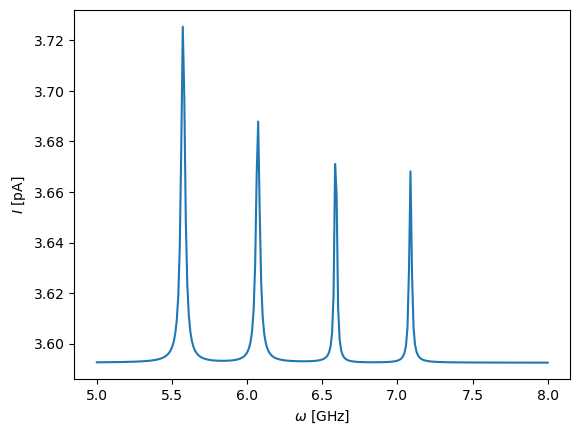

In [5]:
freq_steady = np.linspace(5., 8., 300)
I_steady = np.zeros((len(freq_steady)), dtype=complex)
M = PyESRSTM.QME_matrix(G, dot.Delta, )
for i, f in enumerate(freq_steady   ):
    rho = PyESRSTM.QME(M.copy(), f, qme_matrix=True)
    I_steady[i] = PyESRSTM.current(rho,GC)[1]

plt.plot(freq_steady, -I_steady)
plt.xlabel(r'$\omega$ [GHz]')
plt.ylabel(r'$I$ [pA]')
plt.show()

In [46]:
from scipy.signal import argrelmax

argmax = argrelmax(-I_steady.real)[0]
fc = freq_steady[argmax][2]
fc

np.float64(6.585284280936455)

In [6]:
Ndim = dot.Delta.shape[0] # 8 

# precalculate M 
GRplus, GRminus = PyESRSTM.rates(dot, Right, 0,  0)
GLplus, GLminus = PyESRSTM.rates(dot, Left, 0,  0)

GL = GLplus + GLminus
GR = GRplus + GRminus

GC0 = (GLplus - GLminus)[:,:,:,:,0]
GC1 = 1j*np.imag(GC0)

G = PyESRSTM.sum_rates(GL, GR)

# static propagator
M0 = PyESRSTM.QME_matrix_propagator(G, dot.Delta)[:,:,:,:,0].reshape(Ndim*Ndim, Ndim*Ndim)  

# time-dependent propagator
M1 = PyESRSTM.QME_matrix_propagator(1j*np.imag(GL), np.zeros_like(dot.Delta))[:,:,:,:,0].reshape(Ndim*Ndim, Ndim*Ndim)  

In [25]:
fc = 6.57 
fm = .1
df = .3
def prep_drive(fc, fm, df):
    fc_rad = fc * (2*np.pi) * PyESRSTM.time_unit 
    fm_rad = fm * (2*np.pi) * PyESRSTM.time_unit 
    df_rad = df * (2*np.pi) * PyESRSTM.time_unit 

    def single_step_adrive_add_hoc(t, rho):
        phase = A*np.cos((fc_rad + df_rad*np.cos(fm_rad*t))* t)
        
        drho = (M0 + M1*phase) @ rho
        return drho

    def GC_adrive_add_hoc(t):
        phase = A*np.cos((fc_rad + df_rad*np.cos(fm_rad*t))* t)
        return GC0 + phase[:, None, None, None, None] * GC1[None, :, :, :, :]

    return single_step_adrive_add_hoc, GC_adrive_add_hoc

In [ ]:
single_step_adrive_add_hoc, GC_adrive_add_hoc = prep_drive(6.57, .1, .3)
kwargs = {'max_step': 0.005, 'method': 'RK45'}

rho0 = np.zeros((Ndim,Ndim), dtype=complex)
rho0[0, 0] = 1

t, rho = PyESRSTM.propagate_density(rho0, 400,  drho_function=single_step_adrive_add_hoc, kwargs=kwargs)
I = PyESRSTM.current_in_time(t, rho, Gt_function=GC_adrive_add_hoc)

plt.plot(t, I.real)

62.83185307179586


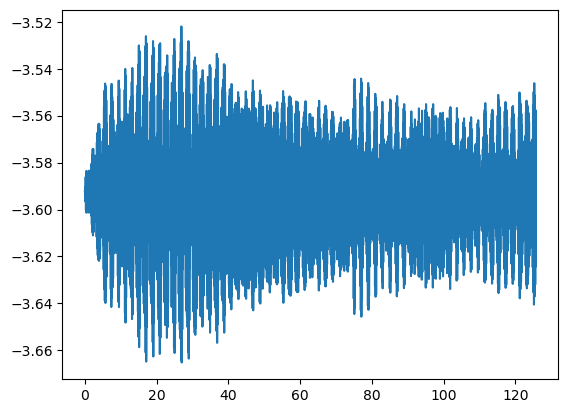

In [ ]:
fc = freq_steady[argmax][2]
fm = .1
df = .3

Tm = 2*np.pi/fm
print(Tm)
kwargs = {'max_step': 0.005, 'method': 'RK45'}
single_step_adrive_add_hoc, GC_adrive_add_hoc = prep_drive(fc, fm, df)


rho0  = PyESRSTM.QME(M.copy(), f, qme_matrix=True)[:,:,1]

t, rho = PyESRSTM.propagate_density(rho0, 2*Tm,  drho_function=single_step_adrive_add_hoc, kwargs=kwargs)
I = PyESRSTM.current_in_time(t, rho, Gt_function=GC_adrive_add_hoc)

plt.plot(t, I.real)

In [47]:
fc = freq_steady[argmax][2]
df = .3

fms = np.linspace(0,.1, 5)
Is = np.zeros_like(fms, )

kwargs = {'max_step': 0.005, 'method': 'RK45'}
#rho0 = PyESRSTM.QME(M.copy(), fc+df, qme_matrix=True)[:,:,1]

for i, fm in enumerate(fms):
    single_step_adrive_add_hoc, GC_adrive_add_hoc = prep_drive(fc, fm, df)
    t, rho = PyESRSTM.propagate_density(rho0, 100,  drho_function=single_step_adrive_add_hoc, kwargs=kwargs)
    
    I = PyESRSTM.current_in_time(t, rho, Gt_function=GC_adrive_add_hoc)

    rho0 = np.average(rho[t>50], axis=0)
    I_avg = np.average(I.real[t>50])
    Is[i] = I_avg
    print(fm, I_avg)

0.0 -3.592995977993648
0.025 -3.594403759367826
0.05 -3.593917335976198
0.07500000000000001 -3.5936518749522475
0.1 -3.5939183602936526


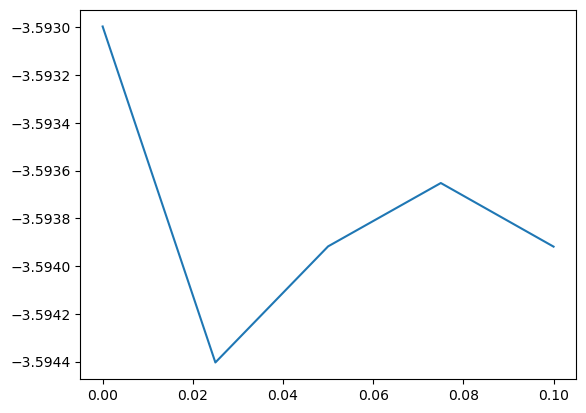

In [48]:
plt.plot(fms, Is)